<a href="https://colab.research.google.com/github/likhithapitta12-collab/HousePricePridiction/blob/main/hr%20prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [ ]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


displayed first 10 rows

In [ ]:
print("rows and columns:", df.shape)

rows and columns: (1470, 35)


checked rows and columns

In [ ]:
print("Target Column:","Attrition")

Target Column: Attrition


indentified target column

In [ ]:
attrition_count = df["Attrition"].value_counts()
print(attrition_count)

Attrition
No     1233
Yes     237
Name: count, dtype: int64


Counts Employees who left Vs Stayed

In [ ]:
attrition_rate = (df["Attrition"].value_counts()["Yes"] / len(df)) * 100
print("Attrition Rate: {:.2f}%".format(attrition_rate))

Attrition Rate: 16.12%


calculates the attrition rate

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

print("Number of Numeric Columns:", len(numeric_cols))
print("Number of Categorical Columns:", len(categorical_cols))

Number of Numeric Columns: 26
Number of Categorical Columns: 9


Numeric vs Categorical Columns

In [ ]:
print("Numeric Columns:")
print(numeric_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numeric Columns:
Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

Categorical Columns:
Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


Display Column Names

The dataset contains employee information used to predict attrition. The Attrition column is the target variable. The number of employees who stayed is much higher than those who left, indicating that the dataset is imbalanced. The attrition rate is 16.12%, meaning only a small percentage of employees left the company. This imbalance should be considered during model training.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

checks dataset information

In [ ]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


checks missing values

In [ ]:
df.duplicated().sum()

np.int64(0)

checks duplicate values

In [ ]:
#remove unnessary columns
df = df.drop(['EmployeeNumber', 'Over18', 'StandardHours'], axis=1)

In [ ]:
#convert target column into numerical values
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [ ]:
#separate features and target
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [ ]:
#One-Hot encoding for categoical columns
X = pd.get_dummies(X, drop_first=True)

In [ ]:
#Scale numerical features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
#Convert scaled data back yo Dataframe
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [ ]:
#check final shape of cleaned dataset
print("Shape after preprocessing:", X_scaled.shape)

Shape after preprocessing: (1470, 45)


In [ ]:

X_scaled.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,0.0,-0.660531,1.383138,0.379672,-0.057788,1.153254,...,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.918921,1.458650,1.591746
1,1.322365,-1.297775,-0.147150,-1.868426,0.0,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,-0.628241
2,0.008343,1.414363,-0.887515,-0.891688,0.0,1.169781,1.284725,-1.026167,-0.961486,0.246200,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650,1.591746
3,-0.429664,1.461466,-0.764121,1.061787,0.0,1.169781,-0.486709,0.379672,-0.961486,0.246200,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,1.591746
4,-1.086676,-0.524295,-0.887515,-1.868426,0.0,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,1.088232,-0.685565,-0.628241


displays first 5 rows

Attrition Rate by Department:
Department
Human Resources           19.047619
Research & Development    13.839750
Sales                     20.627803
Name: Attrition, dtype: float64



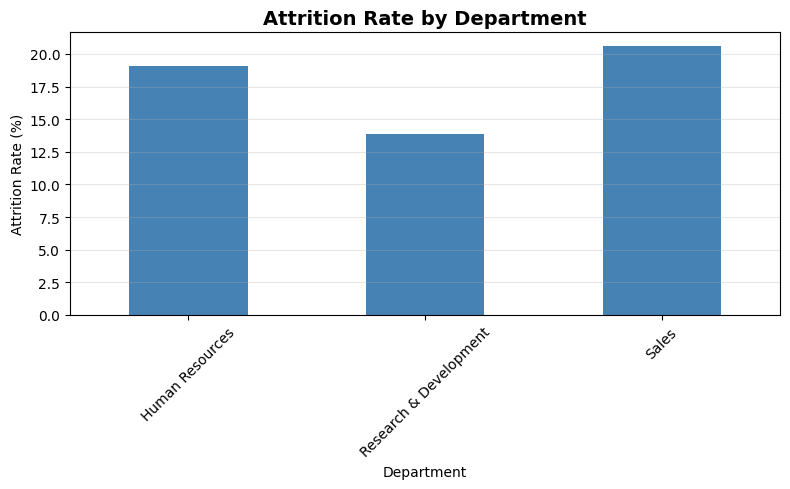

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

# Attrition by Department
attrition_by_dept = df.groupby('Department')['Attrition'].apply(lambda x: (x == 1).sum() / len(x) * 100)
print("Attrition Rate by Department:")
print(attrition_by_dept)
print()

# Visualization
plt.figure(figsize=(8, 5))
attrition_by_dept.plot(kind='bar', color='steelblue')
plt.title('Attrition Rate by Department', fontsize=14, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Attrition Rate by Job Role (Top to Bottom):
JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64



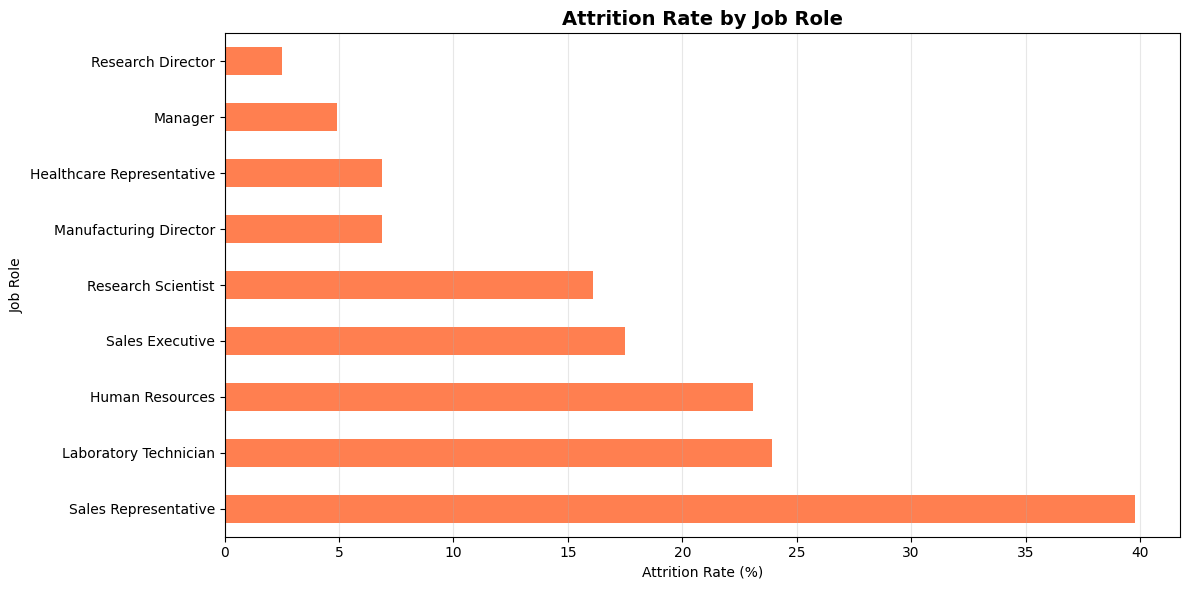

In [ ]:
# Attrition by Job Role
attrition_by_role = df.groupby('JobRole')['Attrition'].apply(lambda x: (x == 1).sum() / len(x) * 100).sort_values(ascending=False)
print("Attrition Rate by Job Role (Top to Bottom):")
print(attrition_by_role)
print()

# Visualization
plt.figure(figsize=(12, 6))
attrition_by_role.plot(kind='barh', color='coral')
plt.title('Attrition Rate by Job Role', fontsize=14, fontweight='bold')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Job Role')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Average Monthly Income by Attrition Status:
Attrition
0    6832.739659
1    4787.092827
Name: MonthlyIncome, dtype: float64



/tmp/ipykernel_8822/2450020581.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='Set2')


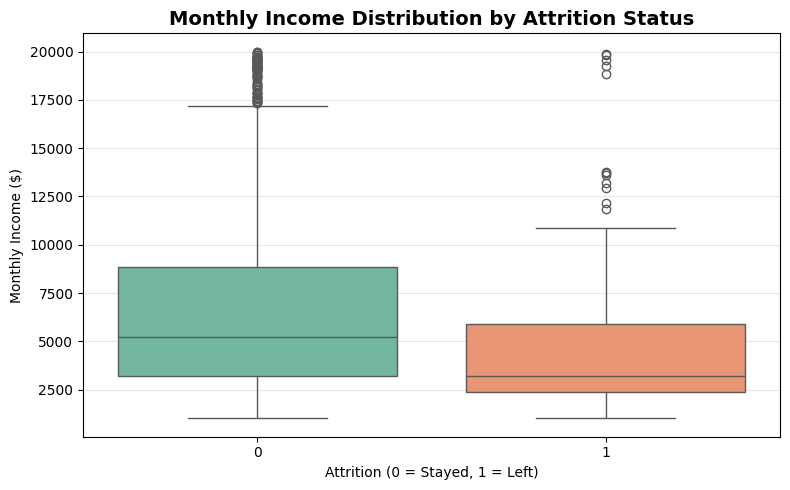

In [ ]:
# Average Monthly Income by Attrition Status
avg_income_by_attrition = df.groupby('Attrition')['MonthlyIncome'].mean()
print("Average Monthly Income by Attrition Status:")
print(avg_income_by_attrition)
print()

# Visualization
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='Set2')
plt.title('Monthly Income Distribution by Attrition Status', fontsize=14, fontweight='bold')
plt.xlabel('Attrition (0 = Stayed, 1 = Left)')
plt.ylabel('Monthly Income ($)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Attrition Rate by Work-Life Balance Rating:
WorkLifeBalance
1    31.250000
2    16.860465
3    14.221725
4    17.647059
Name: Attrition, dtype: float64



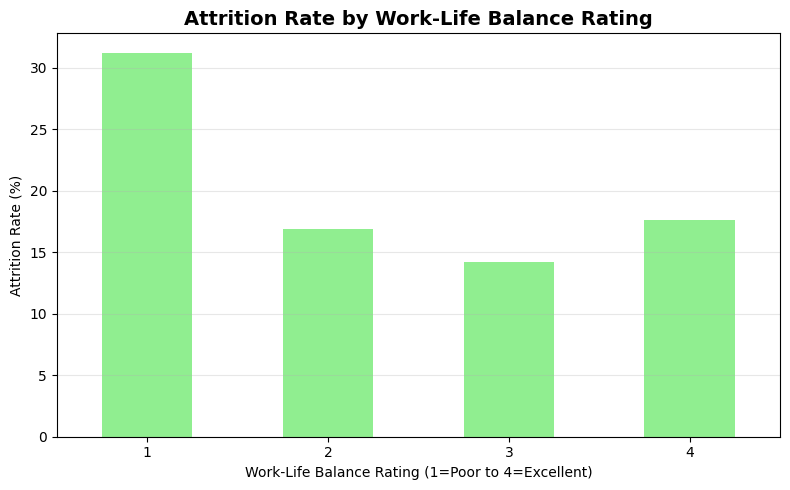

In [ ]:
# Attrition by Work-Life Balance rating
attrition_by_wlb = df.groupby('WorkLifeBalance')['Attrition'].apply(lambda x: (x == 1).sum() / len(x) * 100).sort_index()
print("Attrition Rate by Work-Life Balance Rating:")
print(attrition_by_wlb)
print()

# Visualization
plt.figure(figsize=(8, 5))
attrition_by_wlb.plot(kind='bar', color='lightgreen')
plt.title('Attrition Rate by Work-Life Balance Rating', fontsize=14, fontweight='bold')
plt.xlabel('Work-Life Balance Rating (1=Poor to 4=Excellent)')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Attrition Rate by Years at Company:
YearsAtCompany
0      36.363636
1      34.502924
2      21.259843
3      15.625000
4      17.272727
5      10.714286
6      11.842105
7      12.222222
8      11.250000
9       9.756098
10     15.000000
11      6.250000
12      0.000000
13      8.333333
14     11.111111
15      5.000000
16      8.333333
17     11.111111
18      7.692308
19      9.090909
20      3.703704
21      7.142857
22      6.666667
23     50.000000
24     16.666667
25      0.000000
26      0.000000
27      0.000000
29      0.000000
30      0.000000
31     33.333333
32     33.333333
33     20.000000
34      0.000000
36      0.000000
37      0.000000
40    100.000000
Name: Attrition, dtype: float64



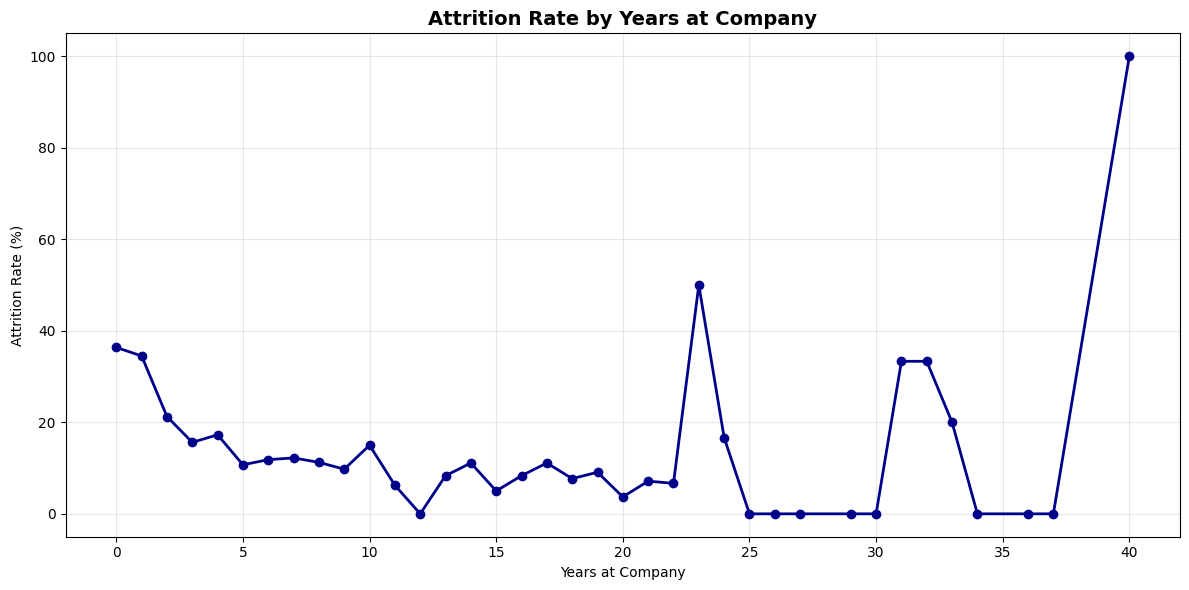

In [ ]:
# Attrition by Years at Company
attrition_by_years = df.groupby('YearsAtCompany')['Attrition'].apply(lambda x: (x == 1).sum() / len(x) * 100)
print("Attrition Rate by Years at Company:")
print(attrition_by_years)
print()

# Visualization
plt.figure(figsize=(12, 6))
attrition_by_years.plot(kind='line', marker='o', color='darkblue', linewidth=2)
plt.title('Attrition Rate by Years at Company', fontsize=14, fontweight='bold')
plt.xlabel('Years at Company')
plt.ylabel('Attrition Rate (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 70)
print("KEY BUSINESS INSIGHTS FROM EDA")
print("=" * 70)

# Insight 1: Department with highest attrition
highest_dept = attrition_by_dept.idxmax()
highest_rate = attrition_by_dept.max()
print(f"\n1. DEPARTMENT INSIGHT:")
print(f"   {highest_dept} has the HIGHEST attrition rate at {highest_rate:.1f}%")

# Insight 2: Job role with highest attrition
highest_role = attrition_by_role.idxmax()
highest_role_rate = attrition_by_role.max()
print(f"\n2. JOB ROLE INSIGHT:")
print(f"   {highest_role} has the HIGHEST attrition rate at {highest_role_rate:.1f}%")

# Insight 3: Income difference
income_diff = avg_income_by_attrition[1] - avg_income_by_attrition[0]
income_pct = (income_diff / avg_income_by_attrition[0]) * 100
print(f"\n3. INCOME INSIGHT:")
print(f"   Employees who LEFT earned ${abs(income_diff):.0f} ({income_pct:.1f}%) LESS than those who STAYED")

# Insight 4: Work-Life Balance impact
wlb_best = attrition_by_wlb.idxmax()
wlb_worst = attrition_by_wlb.idxmin()
print(f"\n4. WORK-LIFE BALANCE INSIGHT:")
print(f"   Rating {wlb_best} has {attrition_by_wlb[wlb_best]:.1f}% attrition (WORST)")
print(f"   Rating {wlb_worst} has {attrition_by_wlb[wlb_worst]:.1f}% attrition (BEST)")

# Insight 5: Tenure insight
early_years = attrition_by_years[attrition_by_years.index <= 2].mean()
print(f"\n5. TENURE INSIGHT:")
print(f"   Employees in first 2 years have {early_years:.1f}% attrition rate")
print(f"   This is a CRITICAL PERIOD for retention efforts")

print("=" * 70)

KEY BUSINESS INSIGHTS FROM EDA

1. DEPARTMENT INSIGHT:
   Sales has the HIGHEST attrition rate at 20.6%

2. JOB ROLE INSIGHT:
   Sales Representative has the HIGHEST attrition rate at 39.8%

3. INCOME INSIGHT:
   Employees who LEFT earned $2046 (-29.9%) LESS than those who STAYED

4. WORK-LIFE BALANCE INSIGHT:
   Rating 1 has 31.2% attrition (WORST)
   Rating 3 has 14.2% attrition (BEST)

5. TENURE INSIGHT:
   Employees in first 2 years have 30.7% attrition rate
   This is a CRITICAL PERIOD for retention efforts


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.model_selection import StratifiedKFold
import joblib


In [ ]:
# Train / Test split (80/20)
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (1176, 45) Test shape: (294, 45)


In [ ]:
# Compute sample weights (balanced)
# This gives each sample a weight inversely proportional to class frequency.
sample_weight_train = compute_sample_weight(class_weight='balanced', y=y_train)


In [ ]:
# Define models (simple default configs)
models = {
    "LogisticRegression": LogisticRegression(solver='liblinear', random_state=42, max_iter=1000),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

In [ ]:
 #Train models
trained_models = {}
for name, model in models.items():
    print(f"Training {name} ...")
    if name == 'GradientBoosting':
        # fit with sample_weight to approximate class balancing
        model.fit(X_train, y_train, sample_weight=sample_weight_train)
    else:
        model.fit(X_train, y_train)
    trained_models[name] = model
    joblib.dump(model, f'{name}_task4.pkl')  # save model
    print(f"{name} trained and saved.")


Training LogisticRegression ...
LogisticRegression trained and saved.
Training RandomForest ...
RandomForest trained and saved.
Training GradientBoosting ...
GradientBoosting trained and saved.


In [ ]:
# Fit models
fitted_models = {}
for name, model in models.items():
    if name == 'GradientBoosting':
        # GradientBoosting doesn't accept class_weight param, so pass sample_weight during fit
        model.fit(X_train, y_train, sample_weight=sample_weight_train)
    else:
        model.fit(X_train, y_train)
    fitted_models[name] = model
    print(f"{name} fitted.")


LogisticRegression fitted.
RandomForest fitted.
GradientBoosting fitted.


In [ ]:
# Evaluate models
results = []
for name, model in fitted_models.items():
    # prediction and probabilities
    y_pred = model.predict(X_test)
    # Some classifiers may not have predict_proba (but these do), safe fallback:
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        # fallback: use decision_function and scale with logistic-like approach (rare here)
        try:
            y_proba = model.decision_function(X_test)
            # If decision_function returns shape (n,), convert to 0-1 via sigmoid
            from scipy.special import expit
            y_proba = expit(y_proba)
        except Exception:
            y_proba = np.zeros_like(y_pred, dtype=float)

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    try:
        roc_auc = roc_auc_score(y_test, y_proba)
    except Exception:
        roc_auc = np.nan
    cm = confusion_matrix(y_test, y_pred)

    results.append({
        'model': name,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'confusion_matrix': cm
    })


In [ ]:
# Build results table (nice formatting)
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'confusion_matrix'} for r in results])
results_df = results_df.set_index('model').round(4)
print("\nComparison table:")
display(results_df)



Comparison table:


,precision,recall,f1,roc_auc
model,,,,
LogisticRegression,0.9286,0.2766,0.4262,0.8119
RandomForest,0.5455,0.1277,0.2069,0.7769
GradientBoosting,0.4000,0.4681,0.4314,0.7782


In [ ]:
# Choose best model
# For imbalanced problems, F1 (for the positive class) is often the most actionable metric.
# We'll select the model with the highest F1 score. You can change to 'roc_auc' if you prefer.
best_by = 'f1'
best_row = results_df[best_by].idxmax()
print(f"\nBest model by {best_by}: {best_row}")

best_model = fitted_models[best_row]


Best model by f1: GradientBoosting


In [ ]:

# Feature importance for best model
feature_names = X.columns.tolist()

def get_feature_importances(model, feature_names, top_n=10):
    if hasattr(model, "coef_"):
        # Logistic Regression: coef_ shape (1, n_features) for binary
        coefs = model.coef_.ravel()
        imp = pd.Series(np.abs(coefs), index=feature_names).sort_values(ascending=False)
        df_imp = pd.DataFrame({
            'feature': imp.index,
            'importance': imp.values,
            'direction': np.sign(coefs)[imp.index]  # +1 positive coef -> higher attrition, -1 lower
        })
    elif hasattr(model, "feature_importances_"):
        fi = model.feature_importances_
        imp = pd.Series(fi, index=feature_names).sort_values(ascending=False)
        df_imp = pd.DataFrame({
            'feature': imp.index,
            'importance': imp.values
        })
    else:
        raise RuntimeError("Model does not expose coef_ or feature_importances_.")
    df_imp = df_imp.reset_index(drop=True)
    return df_imp.head(top_n)

top10 = get_feature_importances(best_model, feature_names, top_n=10)
print("\nTop 10 features for best model:")
display(top10)


Top 10 features for best model:


,feature,importance
0,OverTime_Yes,0.102969
1,MonthlyIncome,0.098556
2,Age,0.084968
3,StockOptionLevel,0.066635
4,YearsWithCurrManager,0.054816
5,NumCompaniesWorked,0.053433
6,DailyRate,0.052183
7,YearsAtCompany,0.044042
8,DistanceFromHome,0.038605
9,EnvironmentSatisfaction,0.035090


In [ ]:

# Save results for notebook record (optional)
results_df.to_csv('model_comparison_results.csv', index=True)
top10.to_csv('best_model_top10_features.csv', index=False)
print("\nSaved model comparison and top-10 features to CSV files.")



Saved model comparison and top-10 features to CSV files.
